## Análisis de vocabulario - proyectos de ley sobre salud

Para controlar la visualizacion usar:
* https://www.color-blindness.com/coblis-color-blindness-simulator/
* https://colorbrewer2.org/#type=diverging&scheme=BrBG&n=3

In [1]:
# Cargar las librerías necesarias
from dotenv import load_dotenv
import pandas as pd
import pickle 
import os
import sys
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
load_dotenv() 
pd.options.display.float_format = '{:.2f}'.format

In [2]:
HEALTH_CYAN = "#0077A8"   # celeste medio
GRAY_MAIN   = "#8F8F8F"
GRAY_LIGHT  = "#E0E0E0"
GRAY_DARK   = "#3A3A3A"

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import locale

#locale.setlocale(locale.LC_ALL, 'es_AR.UTF-8')
#'es_ES.UTF-8'
#'es_ES'
#'spanish'

sns.set_theme(
    style="whitegrid",
    context="notebook",
    palette=[HEALTH_CYAN, GRAY_MAIN, GRAY_LIGHT, GRAY_DARK]
)

plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.titlesize": 14,
    "font.size": 18,
    "axes.titleweight": "bold",
    "axes.labelsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "axes.edgecolor": "#2B2B2B",
    "axes.labelcolor": "#2B2B2B",
    "text.color": "#2B2B2B",
    "grid.color": "#E5E5E5",
    "grid.linestyle": "--",
    "grid.alpha": 0.7,
    "legend.fontsize": 18,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white"
})


### Lectura de datos

In [4]:
# Configurar path
load_dotenv() # Cargar las variables de entorno del archivo .env
BASE_DIR =  os.getenv("DIR_BASE")
RESULTADOS_DIR = os.getenv("DIR_DATOS_PROCESADOS") # Acceder a las variables de entorno
sys.path.append(BASE_DIR)
sys.path.append(RESULTADOS_DIR)

pd.set_option('display.max_colwidth', None)

In [5]:
freqs_df= pd.read_csv(RESULTADOS_DIR+'/archivos_out/frec_para_datos_limpios_por_desplaz_semantico_anios5_all.csv')
freqs_df.head()

,Palabra,Frecuencia,Porcentaje,Período
0,nacional,360,0.04,2019
1,nacional,268,0.03,2014
2,creacion,251,0.02,2019
3,creacion,220,0.02,2014
4,programa,211,0.02,2019


In [6]:
freqs_df['Período'].value_counts()

Período
2014    1969
2019    1876
2009    1717
Name: count, dtype: int64

In [7]:
def pares_primer_paso(lista_items):
    return [(lista_items[i],lista_items[i+1]) for i in range(len(lista_items)-1)]
pares_periodos = pares_primer_paso([2009,2014,2019])
pares_periodos

[(2009, 2014), (2014, 2019)]

In [8]:
from matplotlib_venn import venn2,venn3
print("\n--- Palabras en común entre pares de períodos ---")

for par in pares_periodos:
    periodo1 = par[0]
    periodo2 = par[1]

    vocabulario1 = set(freqs_df[freqs_df['Período'] == int(periodo1)]['Palabra'])
    vocabulario2 = set(freqs_df[freqs_df['Período'] == int(periodo2)]['Palabra'])
    palabras_en_comun = vocabulario1.intersection(vocabulario2)
    union = len(vocabulario1.union(vocabulario2))
    total = len(vocabulario1) + len(vocabulario2)
    
    num_comunes = len(palabras_en_comun)
    print(f"\nPalabras en común entre {periodo1} y {periodo2}: {num_comunes}")
    print(total, union)
    print("%",round((num_comunes/(union+1))*100,3))
    print(list(palabras_en_comun)[1:10])



--- Palabras en común entre pares de períodos ---

Palabras en común entre 2009 y 2014: 1083
3686 2603
% 41.59
['genetico', 'inmunizacion', 'economico', 'odontologia', 'disminuir', 'padecer', 'pensionado', 'conexa', 'desocupado']

Palabras en común entre 2014 y 2019: 1130
3845 2715
% 41.605
['vehiculo', 'prioridad', 'inmunizacion', 'genetico', 'odontologia', 'economico', 'disminuir', 'padecer', 'pensionado']


In [9]:
freqs_df1 = freqs_df[freqs_df['Frecuencia']>5].copy()

for par in pares_periodos:
    periodo1 = par[0]
    periodo2 = par[1]

    vocabulario1 = set(freqs_df1[freqs_df1['Período'] == int(periodo1)]['Palabra'])
    vocabulario2 = set(freqs_df1[freqs_df1['Período'] == int(periodo2)]['Palabra'])
    palabras_en_comun = vocabulario1.intersection(vocabulario2)
    union = len(vocabulario1.union(vocabulario2))
    total = len(vocabulario1) + len(vocabulario2)
    
    num_comunes = len(palabras_en_comun)
    print(f"\nPalabras en común entre {periodo1} y {periodo2}: {num_comunes}")
    print(total, union)
    print("%",round((num_comunes/(union+1))*100,3))
    print(list(palabras_en_comun)[1:10])



Palabras en común entre 2009 y 2014: 212
609 397
% 53.266
['paciente', 'economico', 'prepagar', 'integral', 'obligatoriedad', 'productivo', 'entidad', 'salud', 'pensionado']

Palabras en común entre 2014 y 2019: 229
660 431
% 53.009
['economico', 'paciente', 'prepagar', 'integral', 'obligatoriedad', 'padecer', 'salud', 'entidad', 'articulo']


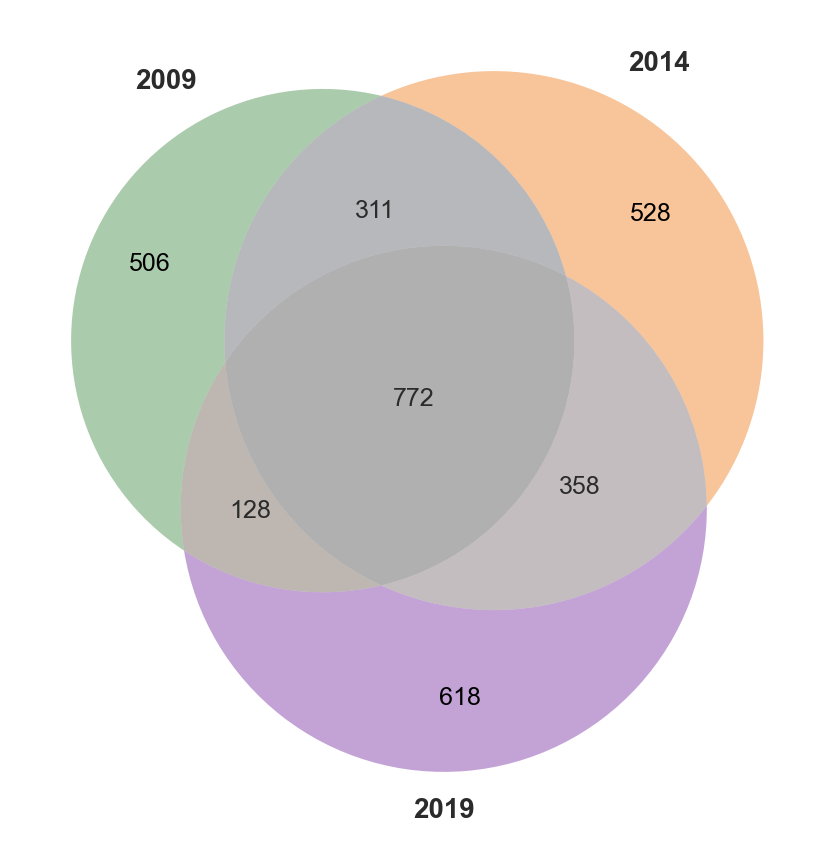

In [31]:
# PALETA ACCESIBLE PARA SALUD - CERTIFICADA WCAG AA
#verde_salud = '#2E8B57'      # Verde principal (conservado)
#azul_medico = '#005C97'       # Azul más oscuro para mejor contraste
#ambar_accesible = '#D35400'   # Ámbar/naranja oscuro distinguible

"""
period_palette = {
    "2009": "#2E4057",   # azul gris oscuro
    "2014": "#8E44AD",   # púrpura medio
    "2019": "#F5B041"    # naranja claro
}
period_palette = {
    "2009": "#1B2A34",   # azul noche más profundo
    "2014": "#7E6A8C",   # púrpura más claro y grisáceo
    "2019": "#B9772E"    # cobre sobrio (lo dejamos igual)
}

"""

period_palette = {
    "2009": "#3F5A2A",   # verde bosque
    "2014": "#7A5C2E",   # mostaza oscuro (no naranja)
    "2019": "#4B3F72"    # violeta frío
}
period_palette = {
    "2009": "#2E7D32",
    "2014": "#EF6C00",
    "2019": "#6A1B9A"
}

plt.figure(figsize=(14, 10))
vocabulario1 = set(freqs_df[freqs_df['Período'] == 2009]['Palabra'])
vocabulario2 = set(freqs_df[freqs_df['Período'] == 2014]['Palabra'])
vocabulario3 = set(freqs_df[freqs_df['Período'] == 2019]['Palabra'])

v = venn3([vocabulario1, vocabulario2, vocabulario3], set_labels=(2009, 2014, 2019))

# Asignar colores ACCESIBLES
v.get_patch_by_id('100').set_facecolor(period_palette['2009'])      # 2009
#v.get_patch_by_id('100').set_alpha(0.6)

v.get_patch_by_id('010').set_facecolor(period_palette['2014'])      # 2014  
#v.get_patch_by_id('010').set_alpha(0.6)

v.get_patch_by_id('001').set_facecolor(period_palette['2019'])  # 2019
#v.get_patch_by_id('001').set_alpha(0.6)

# Intersecciones dobles
v.get_patch_by_id('110').set_facecolor('#4B4F59')  # 2009-2014
v.get_patch_by_id('101').set_facecolor('#5A4A3C')  # 2009-2019
v.get_patch_by_id('011').set_facecolor('#6B5A63')  # 2014-2019

# Intersección triple
v.get_patch_by_id('111').set_facecolor('#3A3A3A')



# Opcional: colores de etiquetas
v.get_label_by_id('100').set_color('black')
v.get_label_by_id('010').set_color('black')
v.get_label_by_id('001').set_color('black')

# Aumentar tamaño de los valores numéricos (intersecciones)
for label_id in ['100', '010', '001', '110', '101', '011', '111']:
    label = v.get_label_by_id(label_id)
    if label:
        label.set_fontsize(18)      
        #label.set_fontweight('bold')

for text in v.set_labels:
    text.set_fontsize(20)
    text.set_fontweight('bold')

#plt.title('Solapamiento de vocabulario entre los períodos 2009, 2014 y 2019' ,pad=20, fontsize=14, fontweight="bold")
# Ajustar layout
plt.tight_layout()
# Dejar espacio arriba para que no choque con el título
plt.subplots_adjust(top=0.85)

# Guardar en alta calidad para accesibilidad
plt.savefig(BASE_DIR+'imagenes/ven_vocabularioPeriodo.png', 
            dpi=300, bbox_inches='tight', 
            facecolor='white', edgecolor='none')

plt.show()

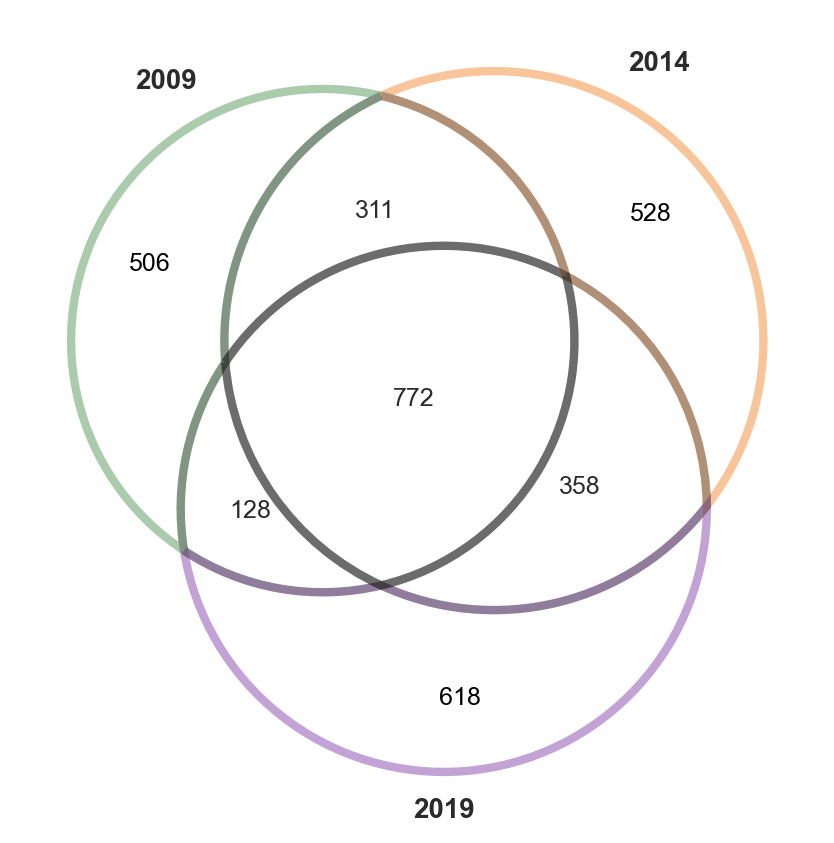

In [30]:

period_palette = {
    "2009": "#3F5A2A",   # verde bosque
    "2014": "#7A5C2E",   # mostaza oscuro (no naranja)
    "2019": "#4B3F72"    # violeta frío
}
period_palette = {
    "2009": "#2E7D32",
    "2014": "#EF6C00",
    "2019": "#6A1B9A"
}

plt.figure(figsize=(14, 10))
vocabulario1 = set(freqs_df[freqs_df['Período'] == 2009]['Palabra'])
vocabulario2 = set(freqs_df[freqs_df['Período'] == 2014]['Palabra'])
vocabulario3 = set(freqs_df[freqs_df['Período'] == 2019]['Palabra'])

v = venn3([vocabulario1, vocabulario2, vocabulario3], set_labels=(2009, 2014, 2019))

# --- SIN RELLENO: SOLO CONTORNOS ---

# Función helper para aplicar estilo
def set_outline(patch, color):
    if patch:
        patch.set_facecolor('none')   # sin relleno
        patch.set_edgecolor(color)    # color de borde
        patch.set_linewidth(6)      # grosor visible

# Conjuntos individuales
set_outline(v.get_patch_by_id('100'), period_palette['2009'])
set_outline(v.get_patch_by_id('010'), period_palette['2014'])
set_outline(v.get_patch_by_id('001'), period_palette['2019'])

set_outline(v.get_patch_by_id('110'), '#444444')
set_outline(v.get_patch_by_id('101'), '#444444')
set_outline(v.get_patch_by_id('011'), '#444444')

set_outline(v.get_patch_by_id('111'), '#000000')  # intersección triple bien marcada
# Opcional: colores de etiquetas
v.get_label_by_id('100').set_color('black')
v.get_label_by_id('010').set_color('black')
v.get_label_by_id('001').set_color('black')

# Aumentar tamaño de los valores numéricos (intersecciones)
for label_id in ['100', '010', '001', '110', '101', '011', '111']:
    label = v.get_label_by_id(label_id)
    if label:
        label.set_fontsize(18)      
        #label.set_fontweight('bold')

for text in v.set_labels:
    text.set_fontsize(20)
    text.set_fontweight('bold')

#plt.title('Solapamiento de vocabulario entre los períodos 2009, 2014 y 2019' ,pad=20, fontsize=14, fontweight="bold")
# Ajustar layout
plt.tight_layout()
# Dejar espacio arriba para que no choque con el título
plt.subplots_adjust(top=0.85)

# Guardar en alta calidad para accesibilidad
plt.savefig(BASE_DIR+'imagenes/ven_vocabularioPeriodo.png', 
            dpi=300, bbox_inches='tight', 
            facecolor='white', edgecolor='none')

plt.show()

A partir de la base de datos integrada de 92.535 proyectos correspondientes a los períodos parlamentarios 127 a 141 (años 2009–2024), se recopilaron los títulos de los proyectos de
ley con el fin de construir el corpus analizado. Para el preprocesamiento específico del subcorpus de salud, se consideraron inicialmente los 33.097 títulos de proyectos de ley
disponibles con el fin de caracterizar el vocabulario legislativo - jurídico. 
El preprocesamiento redujo de manera sustancial la dimensionalidad y variabilidad del vocabulario, así como en la longitud media de los títulos en ambos corpus. Por ejemplo,
en los proyectos de ley sobre salud, la longitud promedio disminuyó de 19,25 a 9,77 tokens tras la limpieza, mientras que el número de tokens únicos se redujo en un 50,9 %. Estos
cambios reflejan la eliminación de ruido, la normalización y pérdida de contexto. Lo cual afecta la disponibilidad de datos y calidad de word embeddings.

#### Palabras emergentes

* Objetivo: detectar palabras que aparecen o aumentan significativamente su uso en un período respecto a otro.

In [11]:
Vocab_periodo_df =  pd.pivot_table(freqs_df, values=['Frecuencia'], columns=['Período'],
                      index=['Palabra']).reset_index()

Vocab_periodo_df.columns = [col[1] if col[1] else col[0] for col in Vocab_periodo_df.columns]
Vocab_periodo_df.fillna(0, inplace=True) # Rellenar valores faltantes con 0
Vocab_periodo_df

,Palabra,2009,2014,2019
0,1a1,0.00,2.00,0.00
1,1a2,0.00,2.00,0.00
2,abastecimiento,0.00,0.00,2.00
3,abdominal,0.00,1.00,0.00
4,abierto,0.00,2.00,4.00
...,...,...,...,...
3216,zonal,1.00,0.00,0.00
3217,zoonosis,0.00,3.00,1.00
3218,zoonotica,1.00,1.00,0.00
3219,zooterapia,1.00,0.00,0.00


In [12]:
# log-odds ratio (con o sin prior bayesiano)

In [13]:
pares_periodos

[(2009, 2014), (2014, 2019)]

In [14]:
RED_HEALTH   = "#7A2E2E"
GREEN_HEALTH = "#8FBFA8"

In [15]:
from matplotlib.colors import LinearSegmentedColormap

# Crear colormap divergente personalizado
custom_cmap = LinearSegmentedColormap.from_list(
    "custom_diverging",
    [RED_HEALTH,'#F5F5F5',GREEN_HEALTH]
    #["#253494" , "#F5F5F5", "#D95F0E"   ]
    #['#4A148C',"#F5F5F5",'#FFB300']
    #["#3B4CC0","#F5F5F5","#B40426"]
    #['#8E0038', "#F5F5F5", '#1B5E20']
    #["#D81B60", "#F5F5F5", "#2E7D32"]  # rosa → blanco → verde
)

def visualizar_top_odds_ratios(df, columna_lor, n=20, title="Top palabras por Log-Odds Ratio"):
    """
    Visualiza las N palabras con los log-odds ratios más altos y más bajos.

    Args:
        df (pd.DataFrame): DataFrame con los resultados del análisis LOR.
        columna_lor (str): Nombre de la columna que contiene los valores de LOR.
        n (int): Número de palabras a mostrar en cada extremo.
        title (str): Título del gráfico.
    """
    top_n = df.sort_values(by=columna_lor, ascending=False).head(n)
    bottom_n = df.sort_values(by=columna_lor, ascending=True).head(n)
    combined = pd.concat([top_n, bottom_n]).sort_values(by=columna_lor, ascending=False)
    
    plt.figure(figsize=(16, 12))  # Más alto para que respire cada palabra
    
    # Ordenar por LOR para mejor lectura
    #combined_sorted = combined.sort_values(by=columna_lor)

    # Normalizar valores para mapear colores
    norm = plt.Normalize(combined[columna_lor].min(),
                     combined[columna_lor].max())

    # Generar lista de colores (ahora sí iterable)
    colors = [custom_cmap(norm(val)) for val in combined[columna_lor]]
    
    ax = sns.barplot(
        x=columna_lor, 
        y=combined.Palabra, 
        data=combined,
        palette= colors #"coolwarm"
    )
    
    # ----- TÍTULOS Y EJES -----
    #plt.title(title, fontsize=18, fontweight='bold', pad=25)
    
    plt.xlabel(
        "Log-Odds Ratio (LOR)", 
        fontsize=14, 
        labelpad=20
    )
    
    plt.ylabel(
        "Término", 
        fontsize=14, 
        fontweight='bold', 
        labelpad=20
    )
    
    # ----- TAMAÑO DE LABELS -----
    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)
    
    # ----- MOSTRAR VALORES NUMÉRICOS DE LOR EN CADA BARRA -----
    for i, v in enumerate(combined[columna_lor]):
        ax.annotate(
            f'{v:.2f}' ,#"{locale.format_string('%.2f', v)}" ,
            xy=(v, i),
            xytext=(0, 5),
            textcoords="offset points",
            va="center",
            ha="left" if v > 0 else "right",
            fontsize=18,
            color="black"
        )
    
    # ----- LIMPIAR ESTÉTICA -----
    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('black')
    ax.spines['bottom'].set_color('black')
    
    # Margen extra para que no se corten los textos
    ax.margins(x=0.15)
    
    # ----- AJUSTES FINALES -----
    plt.tight_layout()
    
    # Guardar en alta calidad para tesis
    plt.savefig(
        BASE_DIR + 'imagenes/' + title.replace(":", "").replace(" ", "_") + '.png',
        dpi=300,
        bbox_inches='tight',
        facecolor='white',
        edgecolor='none'
    )
    
    plt.show()


--- Comparación entre 2009 y 2014 ---
Cantidad de palabras emergentes : 48


,Palabra,Frecuencia_2009,Frecuencia_2014,log_odds_ratio,es_emergente
0,terapeutico,0.00,19.00,3.44,True
1,alto,0.00,16.00,3.28,True
2,libre,0.00,16.00,3.28,True
3,realizacion,0.00,13.00,3.07,True
4,pesquisa,0.00,12.00,3.00,True
5,publicitario,0.00,11.00,2.91,True
6,braille,0.00,11.00,2.91,True
7,riesgo,0.00,11.00,2.91,True
8,traves,0.00,11.00,2.91,True
9,regulatorio,0.00,11.00,2.91,True


C:\Users\Usuario\AppData\Local\Temp\ipykernel_21940\297931664.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


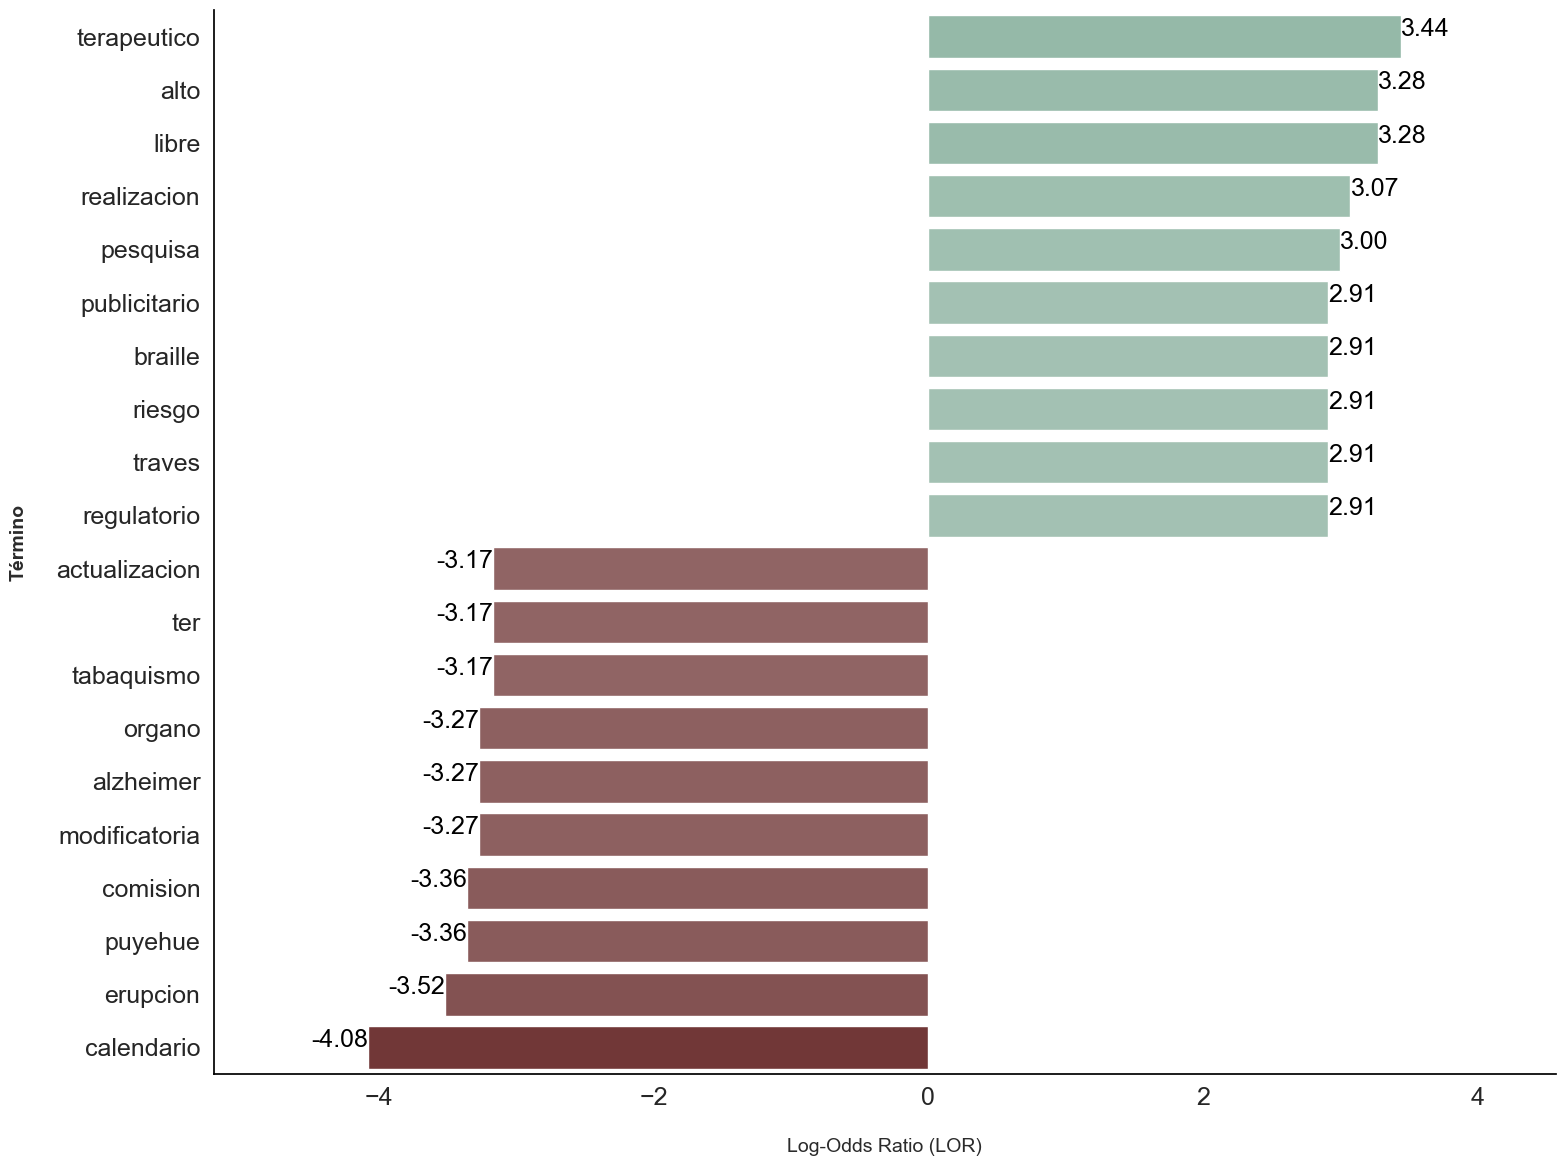


--- Comparación entre 2014 y 2019 ---
Cantidad de palabras emergentes : 46


,Palabra,Frecuencia_2014,Frecuencia_2019,log_odds_ratio,es_emergente
0,covid,0.00,104.00,5.27,True
1,crear,0.00,53.00,4.59,True
2,pandemia,0.00,47.00,4.47,True
3,coronavirus,0.00,24.00,3.81,True
4,acompanamiento,0.00,19.00,3.58,True
5,plasma,0.00,15.00,3.35,True
6,solar,0.00,14.00,3.28,True
7,trabajador,0.00,14.00,3.28,True
8,abordaje,0.00,13.00,3.21,True
9,diciembre,0.00,12.00,3.13,True


C:\Users\Usuario\AppData\Local\Temp\ipykernel_21940\297931664.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


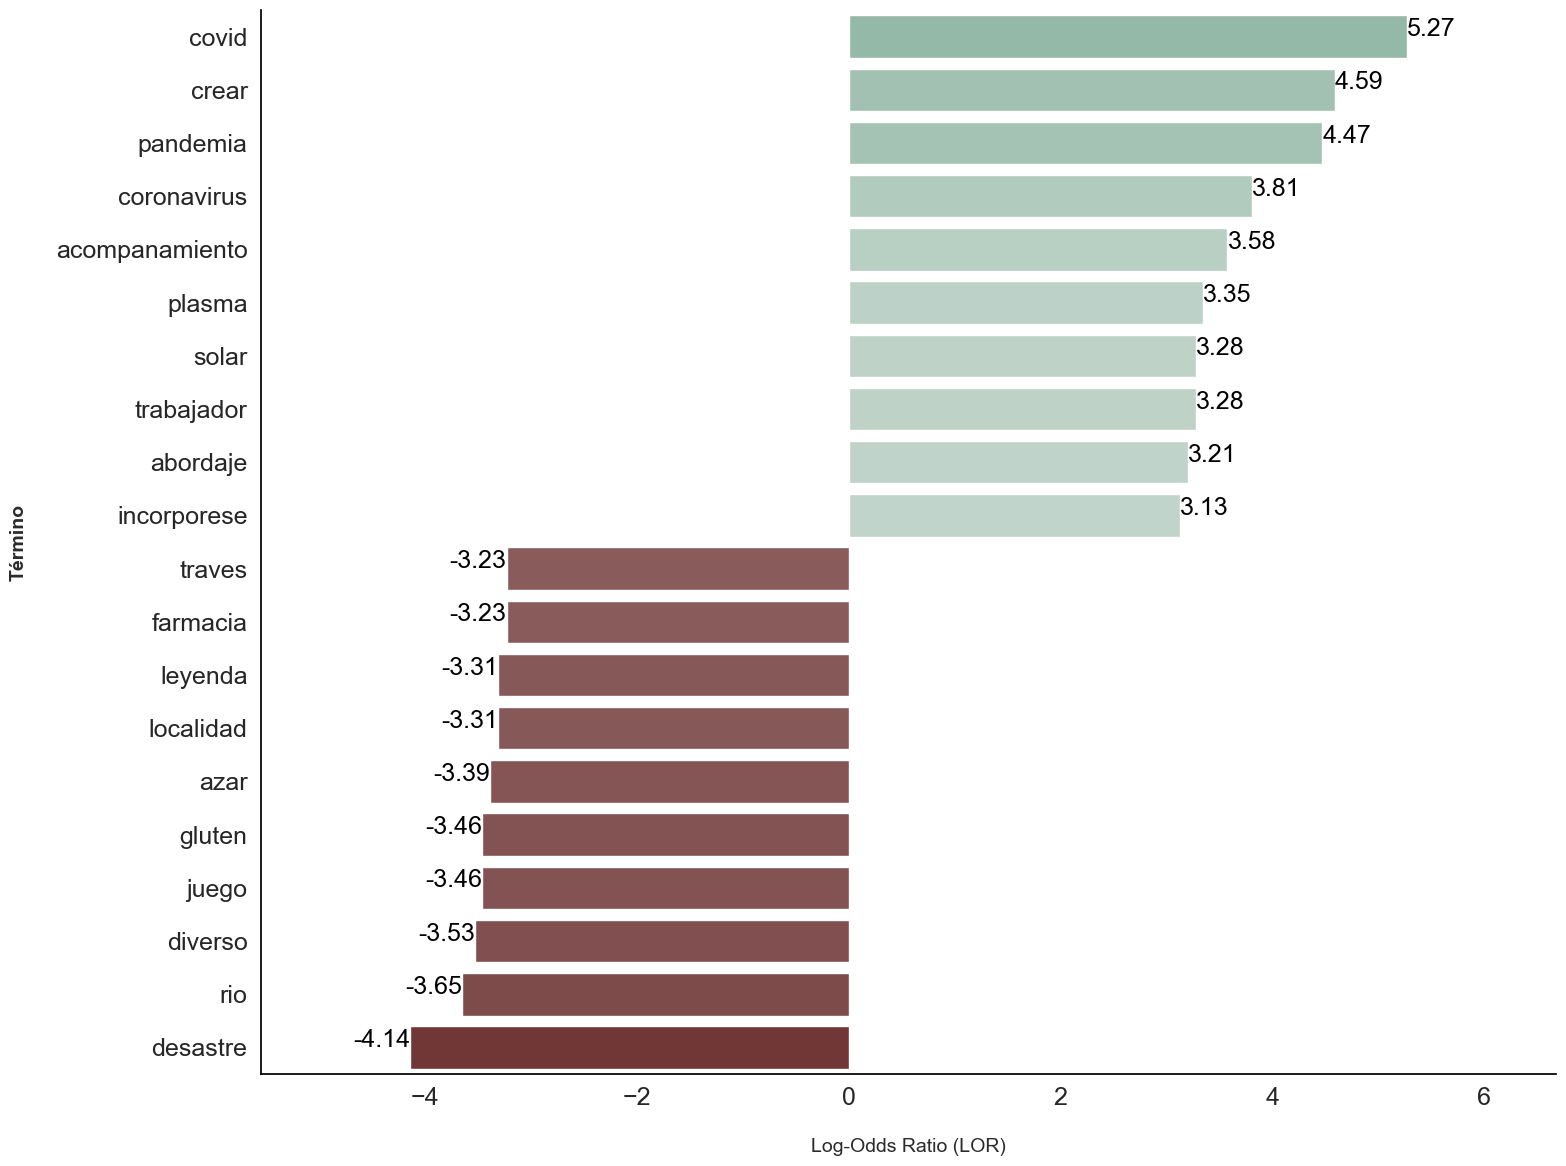

In [16]:
n = 10
for p1, p2 in pares_periodos:
    print(f"\n--- Comparación entre {p1} y {p2} ---")
    periodo_emergente = p2
    periodo_referencia = p1

    resultados_emergentes = pd.read_csv(RESULTADOS_DIR+'/archivos_out/lor_'+str(p1)+'_'+str(p2)+'.csv')
    print("Cantidad de palabras emergentes :",len(resultados_emergentes[resultados_emergentes['es_emergente']==True]))
    display(resultados_emergentes.head(10))
    visualizar_top_odds_ratios(resultados_emergentes, 'log_odds_ratio', n=10, title=f"Top {n} Términos Emergentes : Período {periodo_emergente} vs Período { periodo_referencia}")
